# Week 1 — Floating-Point Arithmetic, Error Analysis & Conditioning

> **Numerical Methods from Scratch** · Pure NumPy + Matplotlib · No SciPy, no black boxes.

Before we solve a single equation, we have to confront an uncomfortable truth: **a computer cannot represent most real numbers.** Every algorithm in this course runs on a finite machine that stores numbers in a finite number of bits. The gap between the real line $\mathbb{R}$ and the finite set $\mathbb{F}$ of *machine numbers* is the source of nearly every subtle bug in scientific computing.

This week we build the foundation:

1. The IEEE-754 floating-point model and **machine epsilon**.
2. **Absolute vs. relative error**, and why relative error is what we usually care about.
3. **Catastrophic cancellation** — how subtracting nearly-equal numbers destroys precision.
4. **Conditioning** of a problem vs. **stability** of an algorithm.
5. **Forward / backward error** and the *rule of thumb* that ties them together.

By the end you will be able to look at a formula and predict *where* it will lose accuracy — a skill more valuable than any single method.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=17)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. The floating-point model

A normalized IEEE-754 double precision number is stored as

$$ x = \pm (1 + f)\, 2^{e}, \qquad f = \sum_{i=1}^{52} b_i\, 2^{-i}, \quad b_i\in\{0,1\}, $$

with an 11-bit exponent $e$ and a 52-bit fraction $f$. The set of all such numbers is denoted $\mathbb{F}$.

The key object is the **unit roundoff** (or machine epsilon) $u$. For double precision,

$$ u = 2^{-53} \approx 1.11\times 10^{-16}. $$

The fundamental axiom of floating-point arithmetic states that for the rounded result $\mathrm{fl}(x)$ of any real $x$ in range,

$$ \mathrm{fl}(x) = x(1+\delta), \qquad |\delta| \le u. $$

In words: **every stored number carries a relative error of at most $u$.** Let us find $u$ empirically — it is the largest number such that $1 + u$ still rounds back to $1$ at the *spacing* level.


In [2]:
# The "epsilon" reported by NumPy is the gap between 1.0 and the next float,
# which is 2*u = 2^-52. Both conventions appear in the literature.
eps_spacing = np.finfo(np.float64).eps          # 2^-52, spacing above 1.0
unit_roundoff = eps_spacing / 2                  # 2^-53, the rounding bound u

print("machine epsilon (spacing 2^-52):", eps_spacing)
print("unit roundoff  u   (2^-53)     :", unit_roundoff)

# Empirical check: find the spacing by halving until 1 + e == 1
e = 1.0
while 1.0 + e != 1.0:
    e /= 2.0
print("smallest e with 1+e==1 found by halving:", e, "-> spacing ~", 2*e)


machine epsilon (spacing 2^-52): 2.220446049250313e-16
unit roundoff  u   (2^-53)     : 1.1102230246251565e-16
smallest e with 1+e==1 found by halving: 1.1102230246251565e-16 -> spacing ~ 2.220446049250313e-16


Notice that `1.0 + e == 1.0` happens when `e` drops *below* half the spacing — rounding to nearest sends it back to `1.0`. This is our first concrete encounter with rounding-to-nearest.

### The number line is not uniform

Floating-point numbers are **logarithmically spaced**: the gap between consecutive numbers grows with magnitude. The gap near $x$ is approximately $u\cdot|x|$ — this is exactly why *relative* error is the natural currency.


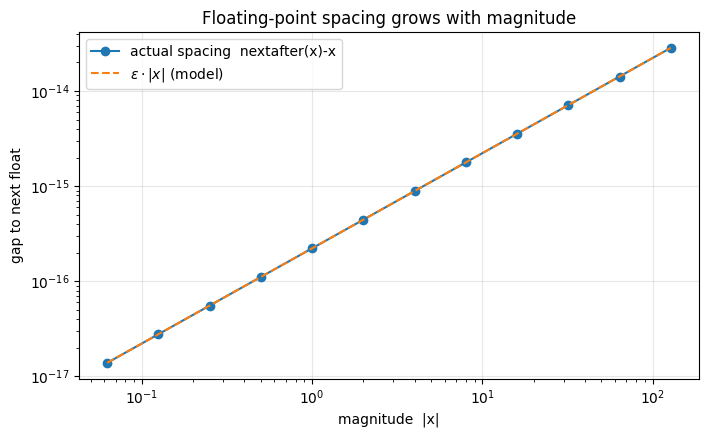

In [3]:
mags = 2.0 ** np.arange(-4, 8)
gaps = np.array([np.nextafter(m, np.inf) - m for m in mags])

fig, ax = plt.subplots()
ax.loglog(mags, gaps, "o-", label="actual spacing  nextafter(x)-x")
ax.loglog(mags, eps_spacing * mags, "--", label=r"$\epsilon \cdot |x|$ (model)")
ax.set_xlabel("magnitude  |x|")
ax.set_ylabel("gap to next float")
ax.set_title("Floating-point spacing grows with magnitude")
ax.legend()
plt.show()


## 2. Absolute vs. relative error

Let $\hat{x}$ approximate a true value $x$. Then

$$ \text{absolute error} = |x - \hat{x}|, \qquad \text{relative error} = \frac{|x-\hat{x}|}{|x|}\;(x\neq 0). $$

Relative error connects directly to **significant digits**: a relative error of $\approx 10^{-k}$ means roughly $k$ correct significant decimal digits. Double precision gives about 15–16 of them.


In [4]:
def errors(true, approx):
    abs_err = abs(true - approx)
    rel_err = abs_err / abs(true) if true != 0 else np.inf
    sig_digits = -np.log10(rel_err) if rel_err > 0 else np.inf
    return abs_err, rel_err, sig_digits

for true, approx in [(np.pi, 3.14159), (1e8, 1e8 + 3), (1e-8, 1.01e-8)]:
    a, r, s = errors(true, approx)
    print(f"true={true:<12g} approx={approx:<14g} abs={a:.3e}  rel={r:.3e}  ~{s:.1f} digits")


true=3.14159      approx=3.14159        abs=2.654e-06  rel=8.447e-07  ~6.1 digits
true=1e+08        approx=1e+08          abs=3.000e+00  rel=3.000e-08  ~7.5 digits
true=1e-08        approx=1.01e-08       abs=1.000e-10  rel=1.000e-02  ~2.0 digits


The middle row is instructive: an absolute error of $3$ looks large, but relative to $10^8$ it is tiny — about 8 correct digits. Context is everything.

## 3. Catastrophic cancellation

This is the single most important failure mode to internalize. When we subtract two nearly-equal numbers, the leading digits cancel and the **relative error explodes**, because the small surviving digits were already contaminated by rounding.

A classic example: the quadratic formula

$$ x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}. $$

When $b^2 \gg 4ac$, the root that uses $-b + \sqrt{b^2-4ac}$ subtracts two nearly equal quantities. Watch it fail, then fix it.


In [5]:
def roots_naive(a, b, c):
    d = np.sqrt(b*b - 4*a*c)
    return ((-b + d) / (2*a), (-b - d) / (2*a))

def roots_stable(a, b, c):
    # Avoid cancellation: compute the "safe" root, then use the product x1*x2 = c/a.
    d = np.sqrt(b*b - 4*a*c)
    if b >= 0:
        x_big = (-b - d) / (2*a)
    else:
        x_big = (-b + d) / (2*a)
    x_small = c / (a * x_big)        # Vieta's formula, no subtraction of equals
    return (x_big, x_small)

a, b, c = 1.0, 1e8, 1.0          # tiny root near -1e-8
print("naive :", roots_naive(a, b, c))
print("stable:", roots_stable(a, b, c))

# The small root should satisfy a*x^2+b*x+c = 0. Check the residual.
xs_naive = roots_naive(a, b, c)[0]
xs_stable = roots_stable(a, b, c)[1]
print("residual naive  small root:", a*xs_naive**2 + b*xs_naive + c)
print("residual stable small root:", a*xs_stable**2 + b*xs_stable + c)


naive : (np.float64(-7.450580596923828e-09), np.float64(-100000000.0))
stable: (np.float64(-100000000.0), np.float64(-1e-08))
residual naive  small root: 0.2549419403076172
residual stable small root: 1.1102230246251565e-16


The naive small root carries a residual many orders of magnitude larger than the stable one. **Same mathematics, radically different accuracy** — that is the difference between a stable and an unstable algorithm.

### A second cancellation example: $1 - \cos x$ for small $x$

For tiny $x$, $\cos x \approx 1$, so $1 - \cos x$ subtracts near-equal numbers. The identity $1-\cos x = 2\sin^2(x/2)$ sidesteps the subtraction entirely.


In [6]:
xs = np.logspace(-9, -1, 9)
naive = 1 - np.cos(xs)
stable = 2 * np.sin(xs/2)**2
exact = xs**2 / 2 * (1 - xs**2/12)     # Taylor reference, accurate for small x

print(f"{'x':>10} {'naive':>14} {'stable':>14} {'rel.err naive':>16}")
for x, n, s in zip(xs, naive, stable):
    ref = x**2/2*(1 - x**2/12)
    rel = abs(n - ref)/abs(ref)
    print(f"{x:10.1e} {n:14.6e} {s:14.6e} {rel:16.2e}")


         x          naive         stable    rel.err naive
   1.0e-09   0.000000e+00   5.000000e-19         1.00e+00
   1.0e-08   0.000000e+00   5.000000e-17         1.00e+00
   1.0e-07   4.996004e-15   5.000000e-15         7.99e-04
   1.0e-06   5.000445e-13   5.000000e-13         8.89e-05
   1.0e-05   5.000000e-11   5.000000e-11         8.27e-08
   1.0e-04   5.000000e-09   5.000000e-09         5.24e-09
   1.0e-03   5.000000e-07   5.000000e-07         1.57e-11
   1.0e-02   4.999958e-05   4.999958e-05         2.81e-11
   1.0e-01   4.995835e-03   4.995835e-03         2.78e-07


For $x = 10^{-9}$ the naive formula has essentially **zero correct digits**, while the rewritten form stays accurate. The lesson: *algebraically equivalent expressions are not numerically equivalent.*

## 4. Conditioning vs. stability

These two words are often confused. Keep them strictly separate:

- **Conditioning** is a property of the *problem*. It measures how much the output changes when the input is perturbed, independent of any algorithm.
- **Stability** is a property of the *algorithm*. A stable algorithm does not amplify rounding errors beyond what the conditioning already forces.

For evaluating a differentiable function $f$ at $x$, the (relative) **condition number** is

$$ \kappa_f(x) = \left| \frac{x\, f'(x)}{f(x)} \right|. $$

It answers: *a 1% change in the input causes roughly a $\kappa$% change in the output.* When $\kappa \gg 1$ the problem is **ill-conditioned**, and no algorithm — however clever — can deliver an accurate answer from inexact inputs.


In [7]:
def condition_number(f, df, x):
    return abs(x * df(x) / f(x))

# f(x) = ln(x): near x=1 the value ->0 while the derivative stays finite, so kappa blows up.
f  = np.log
df = lambda x: 1.0 / x
xs = np.array([0.5, 0.9, 0.99, 0.999, 1.0001])
for x in xs:
    print(f"x={x:<8} kappa(log)={condition_number(f, df, x):12.4f}")


x=0.5      kappa(log)=      1.4427
x=0.9      kappa(log)=      9.4912
x=0.99     kappa(log)=     99.4992
x=0.999    kappa(log)=    999.4999
x=1.0001   kappa(log)=  10000.5000


In [8]:
# Empirical confirmation: perturb the input by a known relative amount and watch the output.
x0 = 0.999
delta = 1e-6                          # relative perturbation of the input
x_pert = x0 * (1 + delta)
rel_out = abs(np.log(x_pert) - np.log(x0)) / abs(np.log(x0))
print("predicted amplification (kappa):", condition_number(f, df, x0))
print("observed  amplification        :", rel_out / delta)


predicted amplification (kappa): 999.4999166249727
observed  amplification        : 999.4994168213996


The observed amplification matches the condition number — the theory is not abstract, it *predicts* the digit loss you will see.

## 5. Forward and backward error

Given an algorithm that computes $\hat{y} \approx f(x)$:

- **Forward error**: $|\hat{y} - f(x)|$ — how wrong is the answer?
- **Backward error**: the smallest $\Delta x$ such that $\hat{y} = f(x + \Delta x)$ *exactly* — for what nearby input would our answer be correct?

The two are linked by the master rule of thumb of numerical analysis:

$$ \boxed{\;\text{forward error} \;\lesssim\; \text{condition number} \times \text{backward error}\;} $$

A *backward-stable* algorithm produces a tiny backward error (on the order of $u$). If the answer is still inaccurate, the conditioning of the problem — not the algorithm — is to blame.


In [9]:
# Illustration with the stable quadratic solver: tiny backward error even when one root is sensitive.
a, b, c = 1.0, 1e6, 2.0
x_big, x_small = roots_stable(a, b, c)

# Backward error: reconstruct the polynomial whose EXACT roots are (x_big, x_small)
# via Vieta:  sum = -b/a,  prod = c/a.
b_recon = -(x_big + x_small) * a
c_recon = (x_big * x_small) * a
print("input     b, c :", b, c)
print("implied   b, c :", b_recon, c_recon)
print("backward err b :", abs(b - b_recon)/abs(b))
print("backward err c :", abs(c - c_recon)/abs(c))


input     b, c : 1000000.0 2.0
implied   b, c : 1000000.0 2.0
backward err b : 0.0
backward err c : 0.0


The implied coefficients are essentially identical to the inputs: the algorithm solved a problem *infinitesimally close* to the one we posed. That is backward stability in action.

## Summary

- Machine numbers carry a relative error bounded by the unit roundoff $u \approx 1.1\times 10^{-16}$; spacing grows with magnitude.
- **Relative error** measures significant digits; **absolute error** alone is misleading.
- **Catastrophic cancellation** destroys precision when subtracting near-equal numbers — rewrite formulas to avoid it.
- **Conditioning** belongs to the problem; **stability** belongs to the algorithm; do not blame one for the other.
- forward error $\lesssim$ condition number $\times$ backward error is the lens through which we judge every method in this course.

---

## Exercises

**1. (Variance two ways.)** The "textbook" one-pass variance formula $\frac{1}{n}\sum x_i^2 - \bar{x}^2$ suffers cancellation. Generate `x = 1e9 + np.random.randn(10000)`, compute the variance with (a) the one-pass formula and (b) the two-pass formula $\frac{1}{n}\sum (x_i-\bar{x})^2$. Compare both to `np.var(x)` and explain the discrepancy in terms of cancellation.

**2. (Condition number of subtraction.)** Show analytically that $f(x,y)=x-y$ has condition number $\frac{|x|+|y|}{|x-y|}$ with respect to the input pair. For what inputs does it blow up? Connect this to Exercise 1.

**3. (A series that lies.)** The exponential $e^{-x}$ can be summed directly as $\sum_k \frac{(-x)^k}{k!}$. Implement this for $x=20$ and compare to `np.exp(-20)`. Why is it catastrophically wrong, and how does computing $1/\big(\sum_k \frac{x^k}{k!}\big)$ fix it?

**4. (Backward error of your own.)** Write a function that, given an approximate root $\hat{r}$ of a cubic $p(x)=x^3+ax^2+bx+c$, estimates the backward error: the smallest coefficient perturbation making $\hat{r}$ an exact root. Test it on a root you deliberately corrupt.

**5. (Spacing experiment.)** Empirically measure `np.nextafter(x, inf) - x` across `x = 10.0 ** np.arange(0, 16)` and verify it tracks $u\cdot|x|$. At what magnitude does the spacing exceed 1.0 (i.e., consecutive integers become unrepresentable)?
